<a href="https://colab.research.google.com/github/JohnMaleek/ML/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercise 1
* Load the Human Activity Recognition dataset.
* Create **X** and **y** from `data`. **y** is the "Activity" column.
* Create training and test splits.
* Fit a Gaussian model to the training split.
* Get predictions on the test set.
* Plot plot the confusion matrix for predictions. (2p)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


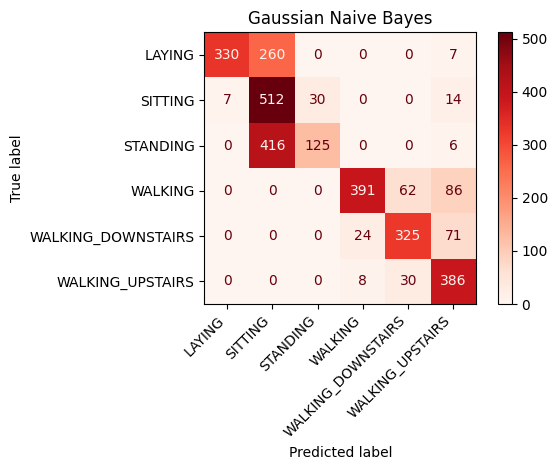

In [8]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import drive

# Mounting the drive to access the dataset  ##Important
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Dataset/Human_Activity_Recognition_Using_Smartphones_Data.csv" #My own drive

# Load the Human Activity Recognition dataset
data = pd.read_csv(file_path)


data.head()

# Create X and y from data. y is the "Activity" column.
X = data[data.columns[:-1]]
y = data.Activity

# Create training and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

GNB = GaussianNB()
GNB.fit(X_train, y_train)

y_pred = GNB.predict(X_test)

            # Calculate the confusion matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Reds')

plt.title("Gaussian Naive Bayes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exercise 2
In the spam.csv file there are more than 5000 records. However, we worked with less than 500 records in our example code. Your task is to develope a better data loader function which load all rows from the spam.csv file into a Pandas data frame. Test the efficiency of the NB model with the extended dataset. (2p)

In [9]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score, recall_score, f1_score
from google.colab import drive

drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Dataset/spam.csv" #my own drive



def load_spam_data_extended(path):
    with open(path, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data = []
    for line in lines[1:]:
        parts = line.split(',', 1)
        if len(parts) >= 2:
            label = parts[0].strip().replace('"', '').lower()
            text = parts[1].split(',,,')[0].strip().replace('"', '')
            if label in ['ham', 'spam']:
                data.append([label, text])

    return pd.DataFrame(data, columns=['label', 'text'])


df = load_spam_data_extended(file_path)
print("Number of rows: {}".format(len(df)))
df.head()

# remove words with numbers
alphanumeric = lambda x: re.sub(r"\w*\d\w*", ' ', str(x))

# remove punctuation and lower case
punc_lower = lambda x: re.sub(r"[{}]".format(re.escape(string.punctuation)), ' ', x.lower())

df['text'] = df.text.map(alphanumeric).map(punc_lower)

df = df.replace(['ham', 'spam'], [0, 1])
df['label'] = df['label'].astype(int)
df.head()



# split the data into a training and test set
X = df.text
y = df.label
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


cv = CountVectorizer(stop_words='english')
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)


nb = MultinomialNB() #NB model
nb.fit(X_train_cv, y_train)
y_pred = nb.predict(X_test_cv)

print("Precision: {:.1f}%".format(precision_score(y_test, y_pred) * 100))
print("Recall:    {:.1f}%".format(recall_score(y_test, y_pred) * 100))
print("F1 score:  {:.1f}%".format(f1_score(y_test, y_pred) * 100))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of rows: 5569
Precision: 93.8%
Recall:    93.8%
F1 score:  93.8%


/tmp/ipykernel_2388/3965736339.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(['ham', 'spam'], [0, 1])
